<a href="https://colab.research.google.com/github/NazmulHudaNabil/cifar10-cnn-streamlit-app/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np

# Load the CIFAR-10 dataset from Keras built-in datasets
# This method ensures you get the full dataset with correct shapes.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten y_train and y_test from (N, 1) to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("CIFAR-10 dataset loaded successfully using tf.keras.datasets!")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
CIFAR-10 dataset loaded successfully using tf.keras.datasets!
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


Now that we have correctly loaded the full dataset, we can proceed with further preprocessing steps like train-validation splitting and one-hot encoding if needed.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Dropout, BatchNormalization, Flatten

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test),batch_size=32 ,verbose=1)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.4901 - loss: 1.4377 - val_accuracy: 0.6038 - val_loss: 1.1319
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.6064 - loss: 1.1176 - val_accuracy: 0.6332 - val_loss: 1.0495
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step - accuracy: 0.6632 - loss: 0.9674 - val_accuracy: 0.6777 - val_loss: 0.9405
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.6971 - loss: 0.8666 - val_accuracy: 0.6809 - val_loss: 0.9224
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.7258 - loss: 0.7906 - val_accuracy: 0.6611 - val_loss: 0.9967
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.7520 - loss: 0.7209 - val_accuracy: 0.7209 - val_loss: 0.8136
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 35ms/step - accuracy: 0.7677 - loss: 0.6691 - val_accuracy: 0.6890 - val_loss: 0.9354
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.7812 -

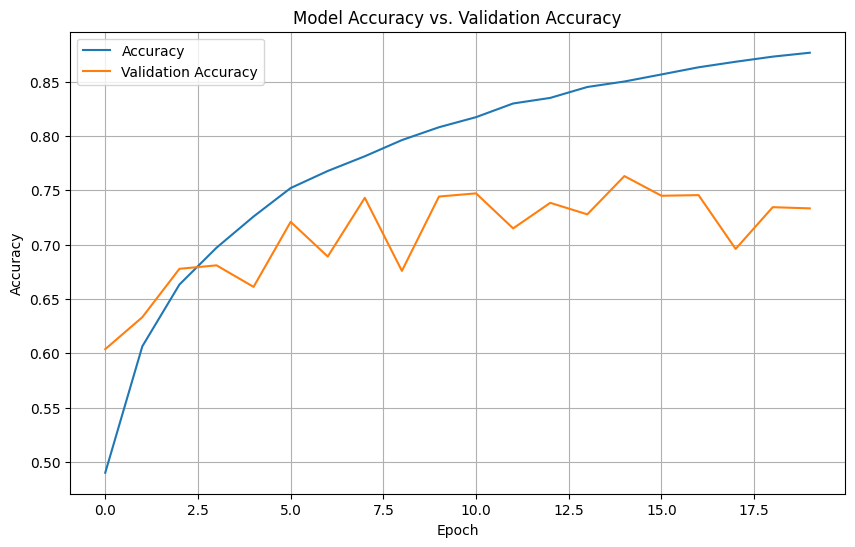

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.save("model_clfar-10.keras")

In [ ]:
import cv2

In [ ]:
test_img = cv2.imread("/content/Low Angle Airplane Image.webp")

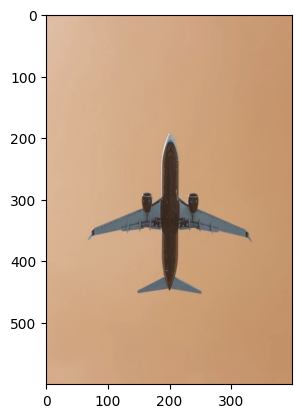

In [ ]:
plt.imshow(test_img)

In [ ]:
test_img.shape

(600, 400, 3)

In [ ]:
test_img = cv2.resize(test_img, (32, 32))

In [ ]:
test_input = test_img.reshape(1, 32, 32, 3)

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
# Your prediction
prediction = model.predict(test_input)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']   # CIFAR-10 example

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

print(f"Predicted class: {predicted_class} → {class_names[predicted_class]}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted class: 0 → airplane
Confidence: 100.00%
